# H4 Hypothesis Testing: Visit Disposition

## Research Question

**Does reported median emergency department length of stay differ across visit disposition categories?**

### Hypotheses

- **H₀:** There is no significant difference in reported median ED length of stay among visit disposition categories.
- **H₁:** There is a significant difference in reported median ED length of stay among visit disposition categories.

### Aggregate-data interpretation

This analysis uses **aggregated emergency department records**. The unit of analysis is an aggregate record, weighted by the reported number of ED visits. Results therefore describe differences in **reported aggregate median LOS across visit disposition categories** and do not support patient-level conclusions.

**Dataset:** `Visit_Disposition.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
# Locate the Visit_Disposition dataset

search_roots = [Path.cwd()] + list(Path.cwd().parents)
candidate_paths = []
for root in search_roots:
    candidate_paths.extend([
        root / "Visit_Disposition.csv",
        root / "data" / "Explorer Dataset" / "Visit_Disposition.csv",
        root / "datasets" / "Visit_Disposition.csv",
        root / "Dataset" / "Visit_Disposition.csv",
        root / "Data" / "Visit_Disposition.csv",
    ])

FILE_PATH = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if FILE_PATH is None:
    matches = []
    for root in search_roots:
        matches.extend(root.rglob("Visit_Disposition.csv"))
    if matches:
        FILE_PATH = matches[0]

assert FILE_PATH is not None, (
    "Visit_Disposition.csv was not found. "
    "Place the dataset in the notebook directory or a data/datasets folder."
)

print("Dataset:", FILE_PATH.resolve())


Dataset: D:\term 5 capstone\capstone offical github repo\Capstone_Project-DAMO-6994-\data\Explorer Dataset\Visit_Disposition.csv


In [6]:
df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (936, 12)


In [7]:
print("FIRST 10 ROWS")
display(df.head(10))


FIRST 10 ROWS


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi
0,2021-2022,2021,Female,Admitted,1,Admitted,0-19,Pediatric & Youth,61448,450,7.5000,27651600
1,2021-2022,2021,Female,Admitted,1,Admitted,20-44,Young Adult,135970,702,11.7000,95450940
2,2021-2022,2021,Female,Admitted,1,Admitted,45-64,Middle Adult,154636,792,13.2000,122471712
3,2021-2022,2021,Female,Admitted,1,Admitted,65+,Older Adult,423379,966,16.1000,408984114
4,2021-2022,2021,Male,Admitted,1,Admitted,0-19,Pediatric & Youth,61089,420,7.0000,25657380
5,2021-2022,2021,Male,Admitted,1,Admitted,20-44,Young Adult,135841,720,12.0000,97805520
6,2021-2022,2021,Male,Admitted,1,Admitted,45-64,Middle Adult,197560,762,12.7000,150540720
7,2021-2022,2021,Male,Admitted,1,Admitted,65+,Older Adult,403171,906,15.1000,365272926
8,2021-2022,2021,Female,Death,0,Not Admitted,0-19,Pediatric & Youth,176,36,0.6000,6336
9,2021-2022,2021,Female,Death,0,Not Admitted,20-44,Young Adult,452,42,0.7000,18984


In [8]:
print("LAST 10 ROWS")
display(df.tail(10))


LAST 10 ROWS


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi
926,2003-2004,2003,Male,Transferred,0,Not Admitted,45-64,Middle Adult,5617,218,3.6300,1224506
927,2003-2004,2003,Male,Transferred,0,Not Admitted,65+,Older Adult,5131,247,4.1200,1267357
928,2003-2004,2003,Female,Unknown,0,Not Admitted,0-19,Pediatric & Youth,6827,54,0.9000,368658
929,2003-2004,2003,Female,Unknown,0,Not Admitted,20-44,Young Adult,7229,60,1.0000,433740
930,2003-2004,2003,Female,Unknown,0,Not Admitted,45-64,Middle Adult,4832,66,1.1000,318912
931,2003-2004,2003,Female,Unknown,0,Not Admitted,65+,Older Adult,4506,90,1.5000,405540
932,2003-2004,2003,Male,Unknown,0,Not Admitted,0-19,Pediatric & Youth,6371,55,0.9200,350405
933,2003-2004,2003,Male,Unknown,0,Not Admitted,20-44,Young Adult,6254,58,0.9700,362732
934,2003-2004,2003,Male,Unknown,0,Not Admitted,45-64,Middle Adult,4659,64,1.0700,298176
935,2003-2004,2003,Male,Unknown,0,Not Admitted,65+,Older Adult,3932,83,1.3800,326356


In [9]:
print("DATASET SHAPE")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")


DATASET SHAPE
Rows: 936
Columns: 12


In [10]:
print("COLUMN NAMES")
for column in df.columns:
    print("-", column)


COLUMN NAMES
- fiscal_year
- fiscal_year_start
- sex
- visit_disposition
- admission_flag
- admission_status
- age_group
- population_category
- ed_visits
- median_los_minutes
- median_los_hours
- erbi


In [11]:
print("DATA TYPES")
display(df.dtypes.to_frame("dtype"))


DATA TYPES


,dtype
fiscal_year,object
fiscal_year_start,int64
sex,object
visit_disposition,object
admission_flag,int64
admission_status,object
age_group,object
population_category,object
ed_visits,int64
median_los_minutes,int64


In [12]:
print("MISSING VALUES")

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (
        df.isna().mean() * 100
    )
})

display(missing_summary)


MISSING VALUES


,missing_count,missing_percent
fiscal_year,0,0.0000
fiscal_year_start,0,0.0000
sex,0,0.0000
visit_disposition,0,0.0000
admission_flag,0,0.0000
admission_status,0,0.0000
age_group,0,0.0000
population_category,0,0.0000
ed_visits,0,0.0000
median_los_minutes,0,0.0000


In [13]:
print("DUPLICATE RECORDS")

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")


DUPLICATE RECORDS
Duplicate rows: 0


In [14]:
print("NUMERICAL SUMMARY")
display(df.describe(include="all").T)


NUMERICAL SUMMARY


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fiscal_year,936,19,2008-2009,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fiscal_year_start,936.0000,NaN,NaN,NaN,"2,011.8205",5.5324,"2,003.0000","2,007.0000","2,012.0000","2,017.0000","2,021.0000"
sex,936,2,Female,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit_disposition,936,7,Admitted,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_flag,936.0000,NaN,NaN,NaN,0.1624,0.3690,0.0000,0.0000,0.0000,0.0000,1.0000
admission_status,936,2,Not Admitted,784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_group,936,4,0-19,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
population_category,936,4,Pediatric & Youth,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ed_visits,936.0000,NaN,NaN,NaN,"187,780.9231","382,287.6388",80.0000,"3,712.0000","21,848.5000","108,355.5000","2,206,226.0000"
median_los_minutes,936.0000,NaN,NaN,NaN,207.8793,162.5662,20.0000,115.7500,168.0000,240.0000,966.0000


In [15]:
print("VISIT DISPOSITION CATEGORIES")

display(
    df["visit_disposition"]
    .value_counts(dropna=False)
    .rename("aggregate_records")
    .to_frame()
)


VISIT DISPOSITION CATEGORIES


,aggregate_records
visit_disposition,
Admitted,152
Death,152
Discharged,152
Intra-Facility Transfer,152
Left Without Being Seen,152
Transferred,152
Unknown,24


In [16]:
print("FISCAL YEAR COVERAGE")

fiscal_year_summary = (
    df.groupby("fiscal_year")
      .agg(
          fiscal_year_start=("fiscal_year_start", "first"),
          aggregate_records=("fiscal_year", "size"),
          total_ed_visits=("ed_visits", "sum")
      )
      .sort_values("fiscal_year_start")
)

display(fiscal_year_summary)


FISCAL YEAR COVERAGE


,fiscal_year_start,aggregate_records,total_ed_visits
fiscal_year,,,
2003-2004,2003,56,4906394
2004-2005,2004,56,5247805
2005-2006,2005,48,5417114
2006-2007,2006,48,5429867
2007-2008,2007,48,5530328
2008-2009,2008,56,5559194
2009-2010,2009,48,5763341
2010-2011,2010,48,8171651
2011-2012,2011,48,9064585


In [17]:
print("ED VISITS AND LOS SUMMARY")

los_summary = (
    df.groupby("visit_disposition")
      .agg(
          aggregate_records=("visit_disposition", "size"),
          total_ed_visits=("ed_visits", "sum"),
          minimum_los_minutes=("median_los_minutes", "min"),
          maximum_los_minutes=("median_los_minutes", "max")
      )
      .reset_index()
)

display(los_summary)


ED VISITS AND LOS SUMMARY


,visit_disposition,aggregate_records,total_ed_visits,minimum_los_minutes,maximum_los_minutes
0,Admitted,152,18004220,235,966
1,Death,152,182003,20,150
2,Discharged,152,145245540,96,246
3,Intra-Facility Transfer,152,909384,36,252
4,Left Without Being Seen,152,8492360,98,180
5,Transferred,152,2786266,164,384
6,Unknown,24,143171,52,104


In [18]:
print("INVALID VALUE CHECKS")

print(
    "Negative ED visits:",
    (df["ed_visits"] < 0).sum()
)

print(
    "Zero ED visits:",
    (df["ed_visits"] == 0).sum()
)

print(
    "Negative median LOS:",
    (df["median_los_minutes"] < 0).sum()
)

print(
    "Negative ERBI:",
    (df["erbi"] < 0).sum()
)

print(
    "Median LOS hours consistency errors:",
    (
        ~np.isclose(
            df["median_los_hours"],
            df["median_los_minutes"] / 60
        )
    ).sum()
)


INVALID VALUE CHECKS
Negative ED visits: 0
Zero ED visits: 0
Negative median LOS: 0
Negative ERBI: 0
Median LOS hours consistency errors: 347


In [19]:
# Ordered visit disposition categories
ordered_dispositions = [
    "Discharged",
    "Admitted",
    "Transferred",
    "Intra-Facility Transfer",
    "Left Without Being Seen",
    "Death",
    "Unknown"
]

print("ORDERED VISIT DISPOSITION CATEGORIES")
for i, category in enumerate(ordered_dispositions, start=1):
    print(f"{i}. {category}")


ORDERED VISIT DISPOSITION CATEGORIES
1. Discharged
2. Admitted
3. Transferred
4. Intra-Facility Transfer
5. Left Without Being Seen
6. Death
7. Unknown


In [21]:
# H4 DATA VALIDATION

required_columns = [
    "fiscal_year",
    "fiscal_year_start",
    "sex",
    "visit_disposition",
    "ed_visits",
    "median_los_minutes",
    "median_los_hours",
    "erbi"
]

missing_required = [
    column
    for column in required_columns
    if column not in df.columns
]

assert not missing_required, (
    f"Missing required columns: {missing_required}"
)

assert (
    df["visit_disposition"].notna().all()
), "Visit disposition contains missing values."

assert (
    df["ed_visits"] > 0
).all(), "ED visit weights must be positive."

assert (
    df["median_los_minutes"] >= 0
).all(), "Median LOS cannot be negative."

unexpected_dispositions = sorted(
    set(df["visit_disposition"].dropna().unique())
    - set(ordered_dispositions)
)

assert not unexpected_dispositions, (
    f"Unexpected disposition categories: {unexpected_dispositions}"
)

print("All H4 validation checks passed.")


All H4 validation checks passed.


In [22]:
# Keep only the disposition categories defined for H4.

h4_df = (
    df[
        df["visit_disposition"].isin(
            ordered_dispositions
        )
    ]
    .copy()
)

h4_df["visit_disposition"] = pd.Categorical(
    h4_df["visit_disposition"],
    categories=ordered_dispositions,
    ordered=True
)

h4_df = h4_df.sort_values(
    "visit_disposition"
).reset_index(drop=True)

print("H4 analysis dataset shape:", h4_df.shape)
display(h4_df.head())


H4 analysis dataset shape: (936, 12)


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi
0,2005-2006,2005,Female,Discharged,0,Not Admitted,0-19,Pediatric & Youth,587687,105,1.7500,61707135
1,2006-2007,2006,Male,Discharged,0,Not Admitted,20-44,Young Adult,757323,124,2.0700,93908052
2,2006-2007,2006,Male,Discharged,0,Not Admitted,45-64,Middle Adult,504756,135,2.2500,68142060
3,2006-2007,2006,Male,Discharged,0,Not Admitted,65+,Older Adult,319394,166,2.7700,53019404
4,2013-2014,2013,Male,Discharged,0,Not Admitted,65+,Older Adult,673703,174,2.9000,117224322


In [23]:
print("WEIGHT VALIDATION")

print(
    "Total ED visit weight:",
    f"{h4_df['ed_visits'].sum():,}"
)

print(
    "Minimum weight:",
    f"{h4_df['ed_visits'].min():,}"
)

print(
    "Maximum weight:",
    f"{h4_df['ed_visits'].max():,}"
)

print(
    "All weights are integer counts:",
    np.allclose(
        h4_df["ed_visits"] % 1,
        0
    )
)


WEIGHT VALIDATION
Total ED visit weight: 175,762,944
Minimum weight: 80
Maximum weight: 2,206,226
All weights are integer counts: True


In [24]:
def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    return np.average(
        values,
        weights=weights
    )


def weighted_median(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    order = np.argsort(values)

    values = values[order]
    weights = weights[order]

    cumulative_weight = np.cumsum(weights)
    cutoff = weights.sum() / 2

    return values[
        np.searchsorted(
            cumulative_weight,
            cutoff,
            side="left"
        )
    ]


In [25]:
h4_summary = (
    h4_df
    .groupby("visit_disposition", observed=True)
    .apply(
        lambda x: pd.Series({

            "records":
                len(x),

            "total_ed_visits":
                x["ed_visits"].sum(),

            "weighted_mean_los_minutes":
                weighted_mean(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "weighted_median_los_minutes":
                weighted_median(
                    x["median_los_minutes"],
                    x["ed_visits"]
                ),

            "minimum_los_minutes":
                x["median_los_minutes"].min(),

            "maximum_los_minutes":
                x["median_los_minutes"].max()

        }),
        include_groups=False
    )
    .reset_index()
)

h4_summary["disposition_order"] = (
    h4_summary["visit_disposition"]
    .astype(str)
    .map({
        category: i
        for i, category in enumerate(ordered_dispositions)
    })
)

h4_summary = (
    h4_summary
    .sort_values("disposition_order")
    .drop(columns="disposition_order")
)

display(h4_summary)


,visit_disposition,records,total_ed_visits,weighted_mean_los_minutes,weighted_median_los_minutes,minimum_los_minutes,maximum_los_minutes
0,Discharged,152.0000,"145,245,540.0000",154.0792,150.0000,96.0000,246.0000
1,Admitted,152.0000,"18,004,220.0000",610.8449,636.0000,235.0000,966.0000
2,Transferred,152.0000,"2,786,266.0000",279.0087,276.0000,164.0000,384.0000
3,Intra-Facility Transfer,152.0000,"909,384.0000",123.2506,136.0000,36.0000,252.0000
4,Left Without Being Seen,152.0000,"8,492,360.0000",139.8949,138.0000,98.0000,180.0000
5,Death,152.0000,"182,003.0000",73.2499,72.0000,20.0000,150.0000
6,Unknown,24.0000,"143,171.0000",68.4133,64.0000,52.0000,104.0000


In [26]:
# Weighted Kruskal-Wallis test for aggregate observations

def weighted_kruskal_wallis(
    data,
    group_col,
    value_col,
    weight_col
):

    test_data = data[
        [group_col, value_col, weight_col]
    ].dropna().copy()

    test_data = test_data[
        test_data[weight_col] > 0
    ].copy()

    if not np.all(
        np.isclose(
            test_data[weight_col] % 1,
            0
        )
    ):
        raise ValueError(
            "Weights must be integer visit counts."
        )

    test_data[weight_col] = (
        test_data[weight_col]
        .astype(np.int64)
    )

    N = int(
        test_data[weight_col].sum()
    )

    value_weights = (
        test_data
        .groupby(value_col)[weight_col]
        .sum()
        .sort_index()
    )

    cumulative_before = (
        value_weights
        .cumsum()
        .shift(fill_value=0)
    )

    weighted_ranks = (
        cumulative_before
        + (value_weights + 1) / 2
    )

    test_data["_rank"] = (
        test_data[value_col]
        .map(weighted_ranks)
    )

    group_stats = (
        test_data
        .groupby(group_col, observed=True)
        .apply(
            lambda x: pd.Series({

                "weight":
                    x[weight_col].sum(),

                "rank_sum":
                    (
                        x["_rank"]
                        * x[weight_col]
                    ).sum()

            }),
            include_groups=False
        )
    )

    H_raw = (
        12 /
        (N * (N + 1))
    ) * (
        (
            group_stats["rank_sum"] ** 2
            /
            group_stats["weight"]
        ).sum()
    ) - (
        3 * (N + 1)
    )

    tie_weights = value_weights.values

    tie_correction = (
        1 -
        (
            np.sum(
                tie_weights ** 3 -
                tie_weights
            )
            /
            (
                N ** 3 -
                N
            )
        )
    )

    H_corrected = (
        H_raw /
        tie_correction
    )

    degrees_freedom = (
        group_stats.shape[0] - 1
    )

    p_value = stats.chi2.sf(
        H_corrected,
        degrees_freedom
    )

    return {
        "H": H_corrected,
        "df": degrees_freedom,
        "p_value": p_value,
        "N_weight": N,
        "tie_correction": tie_correction,
        "group_stats": group_stats
    }


In [27]:
# ============================================================
# WEIGHTED KRUSKAL-WALLIS TEST
# ============================================================

h4_result = weighted_kruskal_wallis(
    data=h4_df,
    group_col="visit_disposition",
    value_col="median_los_minutes",
    weight_col="ed_visits"
)

print("H4 - WEIGHTED KRUSKAL-WALLIS TEST")
print("-" * 80)

print(
    f"Test statistic (H): "
    f"{h4_result['H']:.6f}"
)

print(
    f"Degrees of freedom: "
    f"{h4_result['df']}"
)

print(
    f"P-value: "
    f"{h4_result['p_value']:.10f}"
)

print(
    f"Total frequency weight: "
    f"{h4_result['N_weight']:,}"
)

print(
    f"Tie correction: "
    f"{h4_result['tie_correction']:.10f}"
)


H4 - WEIGHTED KRUSKAL-WALLIS TEST
--------------------------------------------------------------------------------
Test statistic (H): 56590436.666229
Degrees of freedom: 6
P-value: 0.0000000000
Total frequency weight: 175,762,944
Tie correction: 1.0000007223


In [28]:
ALPHA = 0.05

p_value = h4_result["p_value"]

print("=" * 80)
print("H4 HYPOTHESIS DECISION")
print("=" * 80)

print("Significance level (α):", ALPHA)
print(f"P-value: {p_value:.10f}")

if p_value < ALPHA:

    print("\nDecision: REJECT H₀")

    print("\nConclusion:")

    print(
        "There is statistically significant evidence "
        "that reported median ED length of stay differs "
        "across visit disposition categories in the "
        "aggregate Visit_Disposition data."
    )

else:

    print("\nDecision: FAIL TO REJECT H₀")

    print("\nConclusion:")

    print(
        "There is insufficient statistical evidence "
        "to conclude that reported median ED length "
        "of stay differs across visit disposition "
        "categories in the aggregate Visit_Disposition data."
    )


H4 HYPOTHESIS DECISION
Significance level (α): 0.05
P-value: 0.0000000000

Decision: REJECT H₀

Conclusion:
There is statistically significant evidence that reported median ED length of stay differs across visit disposition categories in the aggregate Visit_Disposition data.


In [29]:
H = h4_result["H"]

k = h4_result["df"] + 1

N = h4_result["N_weight"]

epsilon_squared = (
    H - k + 1
) / (
    N - k
)

print("H4 EFFECT SIZE")
print("-" * 80)

print(
    f"Epsilon squared (ε²): "
    f"{epsilon_squared:.10f}"
)


H4 EFFECT SIZE
--------------------------------------------------------------------------------
Epsilon squared (ε²): 0.3219702153


In [30]:
h4_result_table = pd.DataFrame({

    "Hypothesis": [
        "H4"
    ],

    "Research_Question": [
        "Does reported median ED LOS differ across visit disposition categories?"
    ],

    "Test": [
        "Weighted Kruskal-Wallis"
    ],

    "H_Statistic": [
        H
    ],

    "Degrees_of_Freedom": [
        h4_result["df"]
    ],

    "P_Value": [
        p_value
    ],

    "Epsilon_Squared": [
        epsilon_squared
    ],

    "Alpha": [
        ALPHA
    ],

    "Decision": [
        "Reject H0"
        if p_value < ALPHA
        else "Fail to Reject H0"
    ]

})

display(h4_result_table)


,Hypothesis,Research_Question,Test,H_Statistic,Degrees_of_Freedom,P_Value,Epsilon_Squared,Alpha,Decision
0,H4,Does reported median ED LOS differ across visi...,Weighted Kruskal-Wallis,"56,590,436.6662",6,0.0000,0.3220,0.0500,Reject H0


In [31]:
# ============================================================
# H4 VISUALIZATION DATA
# ============================================================

h4_df["visit_disposition"] = pd.Categorical(
    h4_df["visit_disposition"],
    categories=ordered_dispositions,
    ordered=True
)

h4_df = h4_df.sort_values(
    "visit_disposition"
)

chart_labels = [
    str(x)
    for x in ordered_dispositions
]

print("H4 visualization data prepared.")


H4 visualization data prepared.


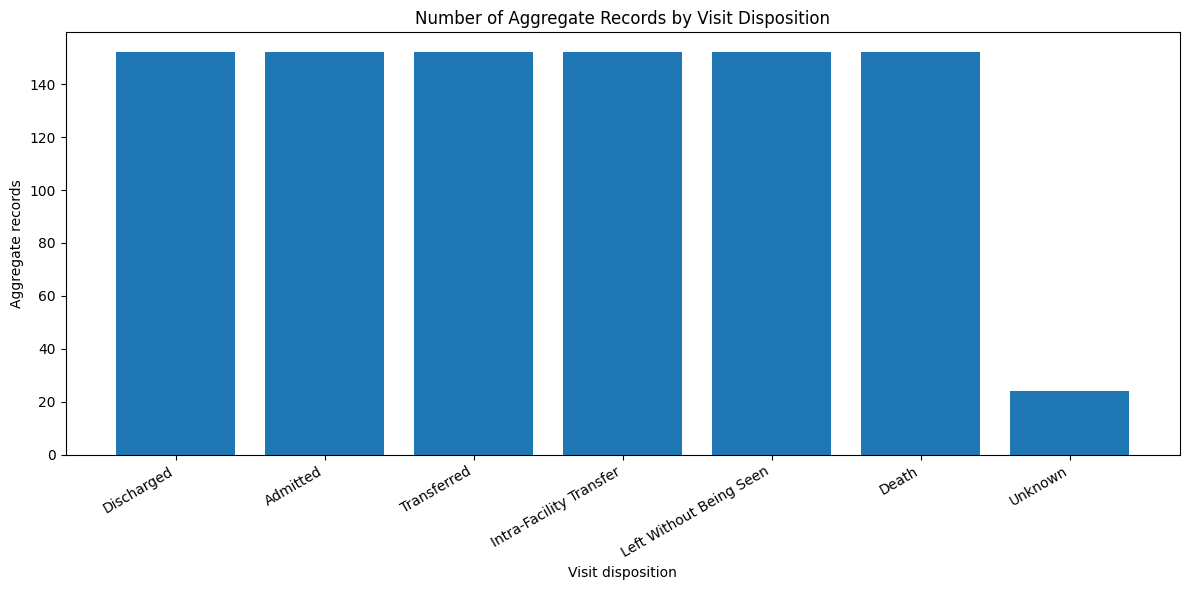

In [32]:
# NUMBER OF AGGREGATE RECORDS BY VISIT DISPOSITION

plot_data = h4_summary.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["visit_disposition"].astype(str),
    plot_data["records"]
)

plt.title("Number of Aggregate Records by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Aggregate records")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


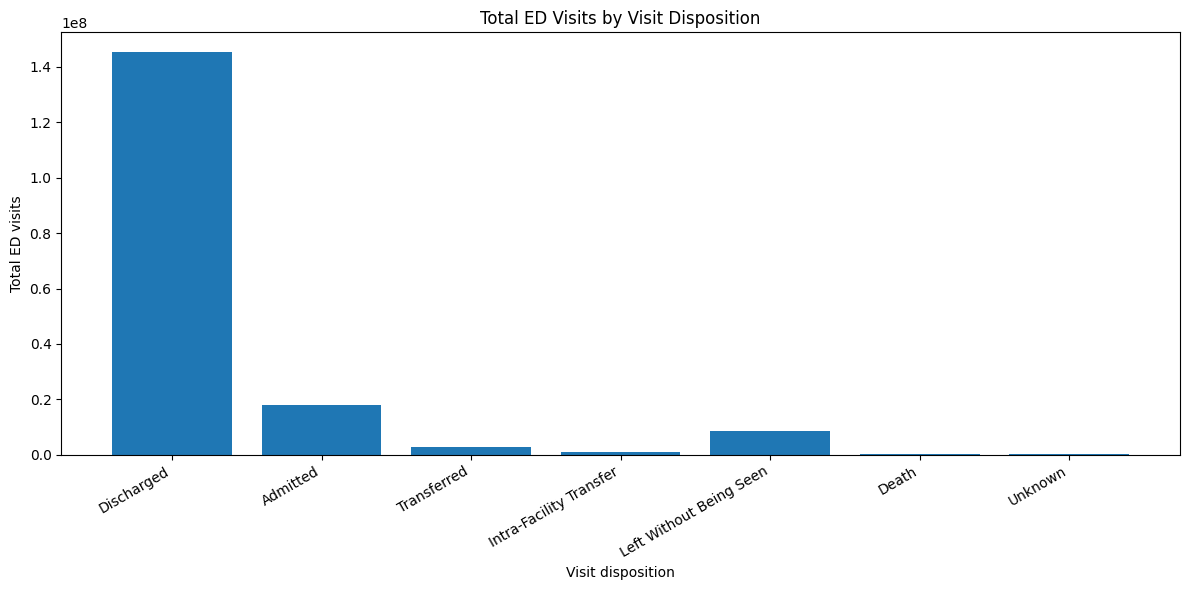

In [33]:
# TOTAL ED VISITS BY VISIT DISPOSITION

plot_data = h4_summary.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["visit_disposition"].astype(str),
    plot_data["total_ed_visits"]
)

plt.title("Total ED Visits by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Total ED visits")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


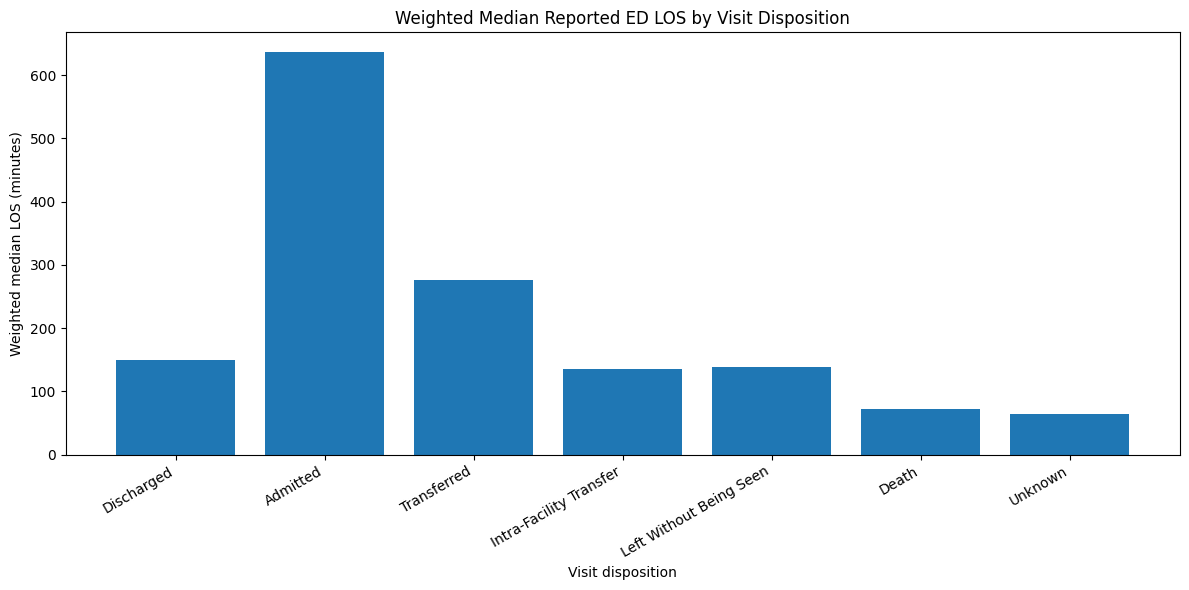

In [34]:
# WEIGHTED MEDIAN LOS BY VISIT DISPOSITION

plot_data = h4_summary.copy()

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["visit_disposition"].astype(str),
    plot_data["weighted_median_los_minutes"]
)

plt.title("Weighted Median Reported ED LOS by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Weighted median LOS (minutes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


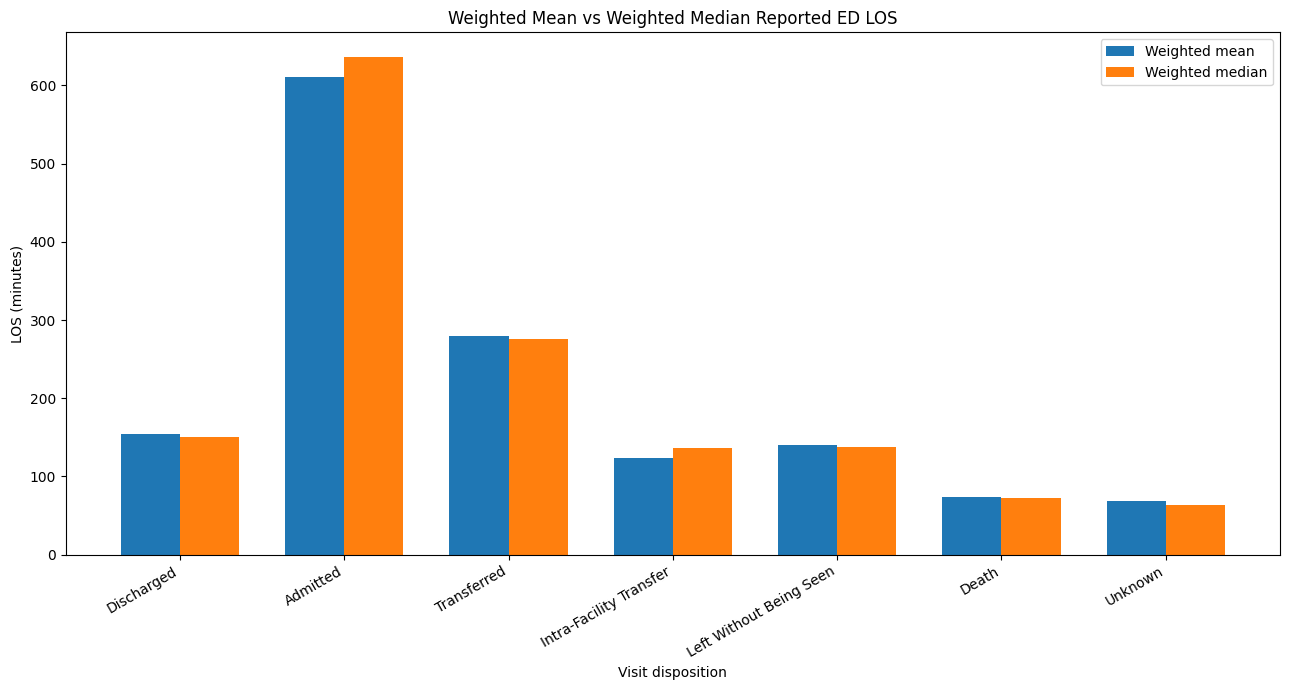

In [35]:
# WEIGHTED MEAN VS WEIGHTED MEDIAN LOS

plot_data = h4_summary.copy()

x = np.arange(len(plot_data))
width = 0.36

plt.figure(figsize=(13, 7))

plt.bar(
    x - width / 2,
    plot_data["weighted_mean_los_minutes"],
    width,
    label="Weighted mean"
)

plt.bar(
    x + width / 2,
    plot_data["weighted_median_los_minutes"],
    width,
    label="Weighted median"
)

plt.title("Weighted Mean vs Weighted Median Reported ED LOS")
plt.xlabel("Visit disposition")
plt.ylabel("LOS (minutes)")
plt.xticks(
    x,
    plot_data["visit_disposition"].astype(str),
    rotation=30,
    ha="right"
)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\moham\AppData\Local\Temp\ipykernel_23772\3932317782.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


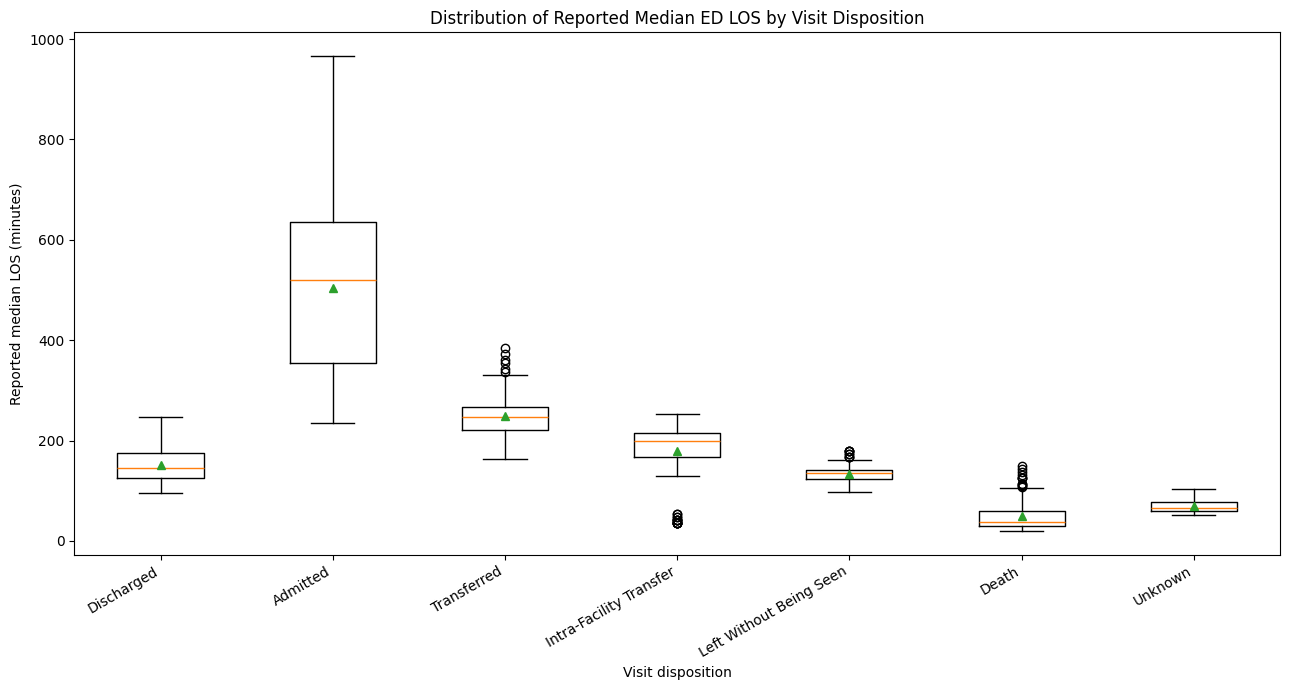

In [36]:
# LOS DISTRIBUTION BY VISIT DISPOSITION

box_data = [
    h4_df.loc[
        h4_df["visit_disposition"] == category,
        "median_los_minutes"
    ].dropna()
    for category in ordered_dispositions
]

plt.figure(figsize=(13, 7))

plt.boxplot(
    box_data,
    labels=ordered_dispositions,
    showmeans=True
)

plt.title("Distribution of Reported Median ED LOS by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Reported median LOS (minutes)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


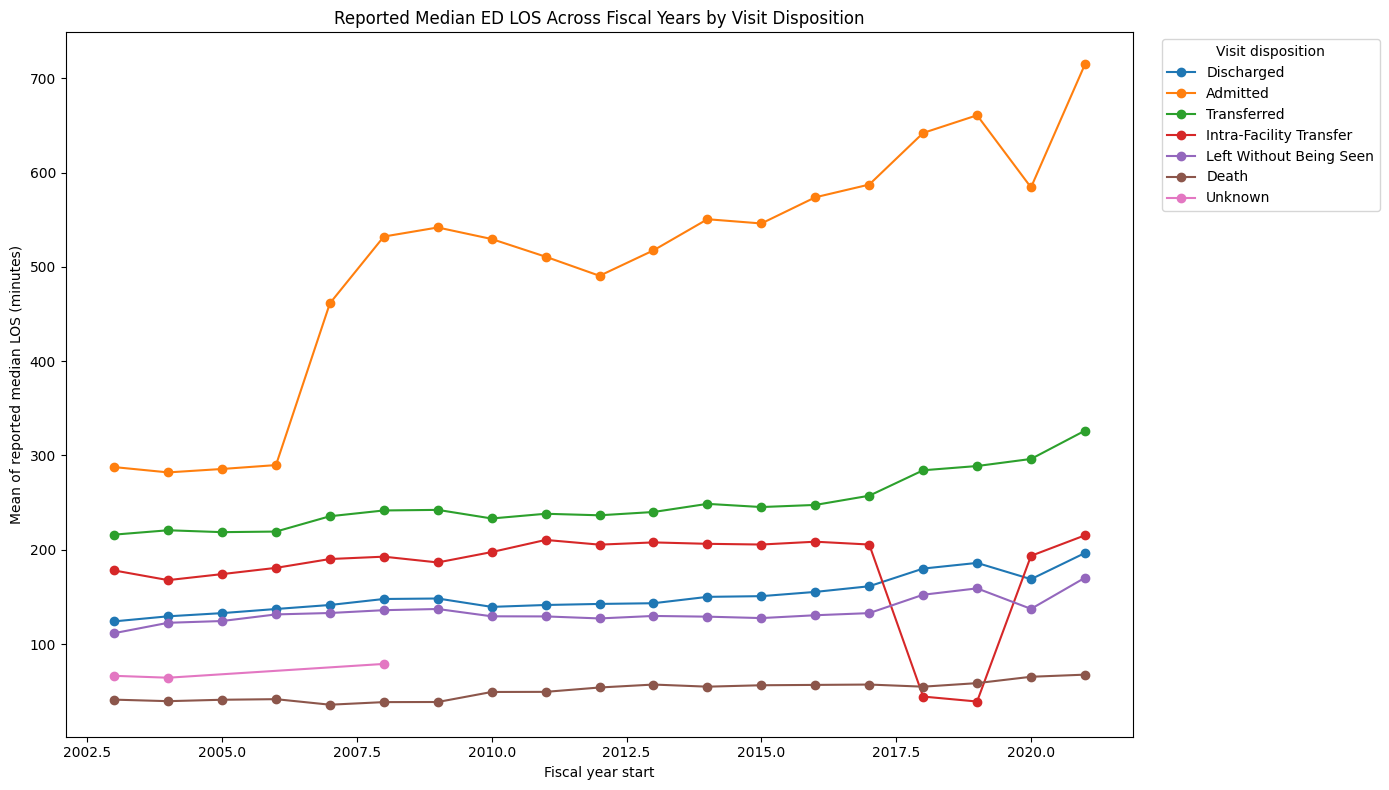

In [37]:
# REPORTED MEDIAN LOS TREND BY FISCAL YEAR

trend = (
    h4_df
    .groupby(
        ["fiscal_year_start", "visit_disposition"],
        observed=True
    )["median_los_minutes"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))

for category in ordered_dispositions:

    subset = trend[
        trend["visit_disposition"] == category
    ]

    if not subset.empty:
        plt.plot(
            subset["fiscal_year_start"],
            subset["median_los_minutes"],
            marker="o",
            label=category
        )

plt.title(
    "Reported Median ED LOS Across Fiscal Years by Visit Disposition"
)
plt.xlabel("Fiscal year start")
plt.ylabel("Mean of reported median LOS (minutes)")
plt.legend(
    title="Visit disposition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


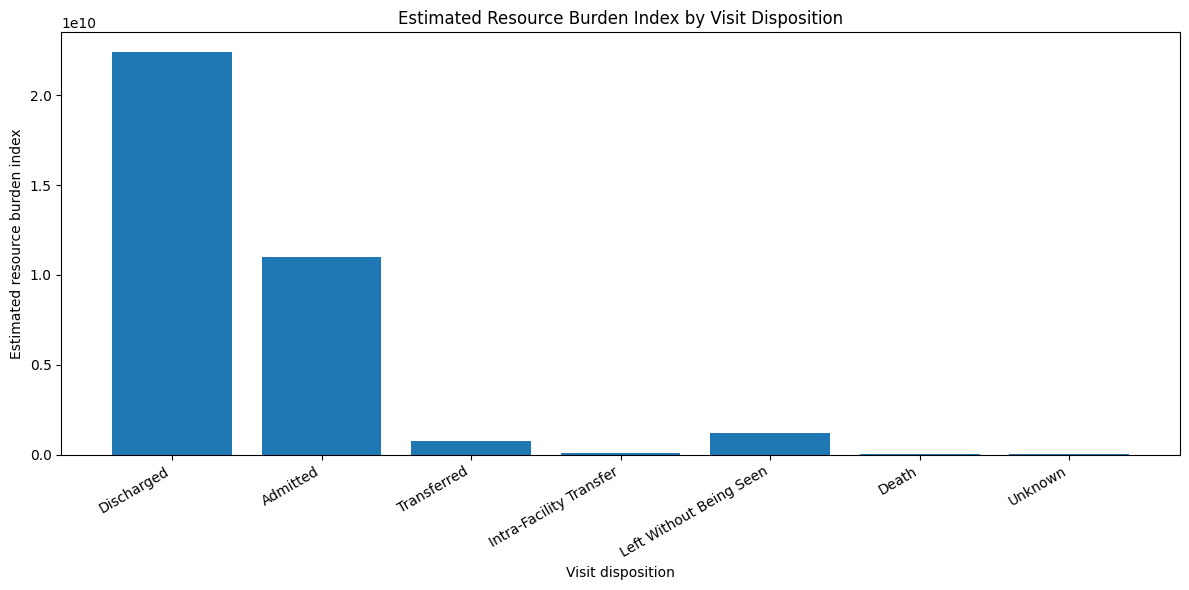

In [38]:
# ESTIMATED RESOURCE BURDEN INDEX BY VISIT DISPOSITION

erbi_summary = (
    h4_df
    .groupby("visit_disposition", observed=True)["erbi"]
    .sum()
    .reindex(ordered_dispositions)
)

plt.figure(figsize=(12, 6))

plt.bar(
    erbi_summary.index.astype(str),
    erbi_summary.values
)

plt.title("Estimated Resource Burden Index by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Estimated resource burden index")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


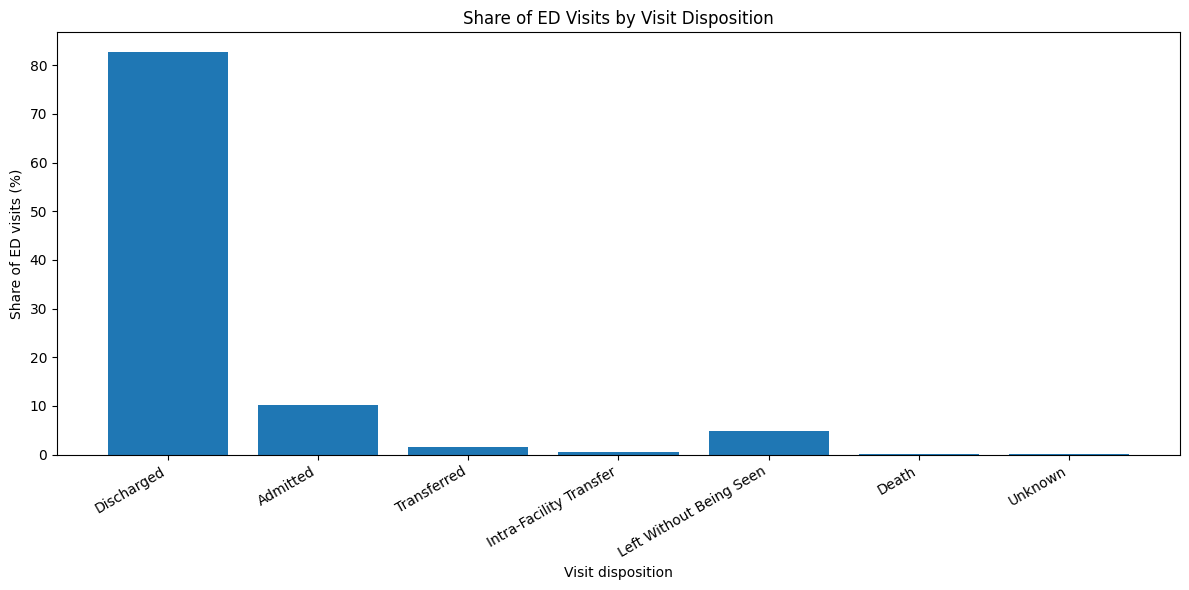

In [39]:
# ED VISIT SHARE BY VISIT DISPOSITION

visit_share = (
    h4_summary
    .set_index("visit_disposition")["total_ed_visits"]
    .reindex(ordered_dispositions)
)

visit_share_percent = (
    visit_share /
    visit_share.sum() *
    100
)

plt.figure(figsize=(12, 6))

plt.bar(
    visit_share_percent.index.astype(str),
    visit_share_percent.values
)

plt.title("Share of ED Visits by Visit Disposition")
plt.xlabel("Visit disposition")
plt.ylabel("Share of ED visits (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


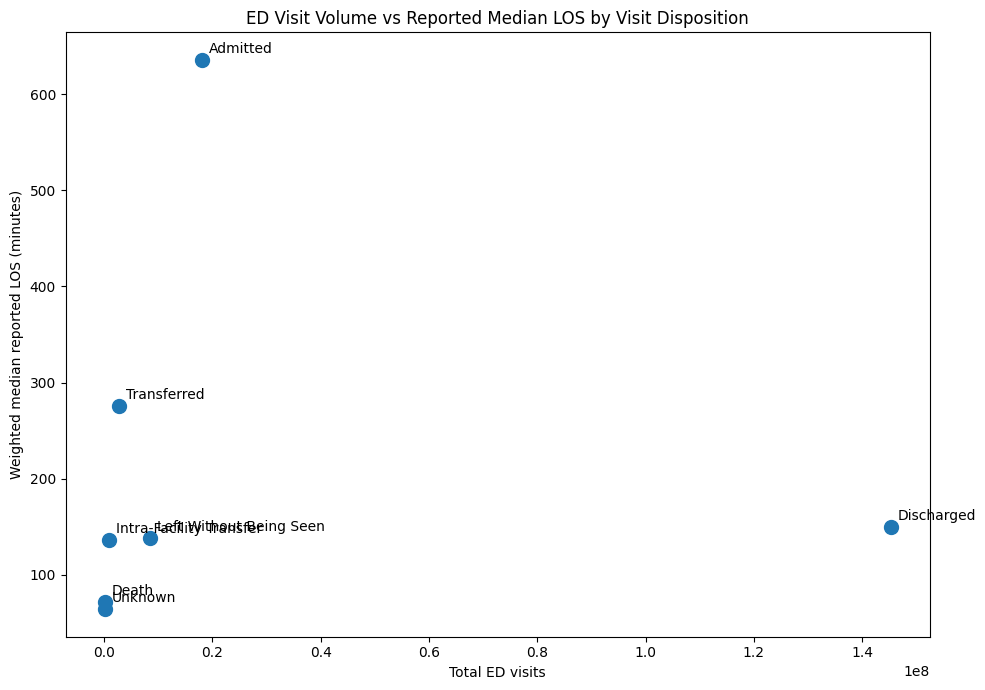

In [40]:
# ED VISIT VOLUME VS REPORTED MEDIAN LOS

plot_data = h4_summary.copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    plot_data["total_ed_visits"],
    plot_data["weighted_median_los_minutes"],
    s=100
)

for _, row in plot_data.iterrows():

    plt.annotate(
        str(row["visit_disposition"]),
        (
            row["total_ed_visits"],
            row["weighted_median_los_minutes"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "ED Visit Volume vs Reported Median LOS by Visit Disposition"
)
plt.xlabel("Total ED visits")
plt.ylabel("Weighted median reported LOS (minutes)")
plt.tight_layout()
plt.show()


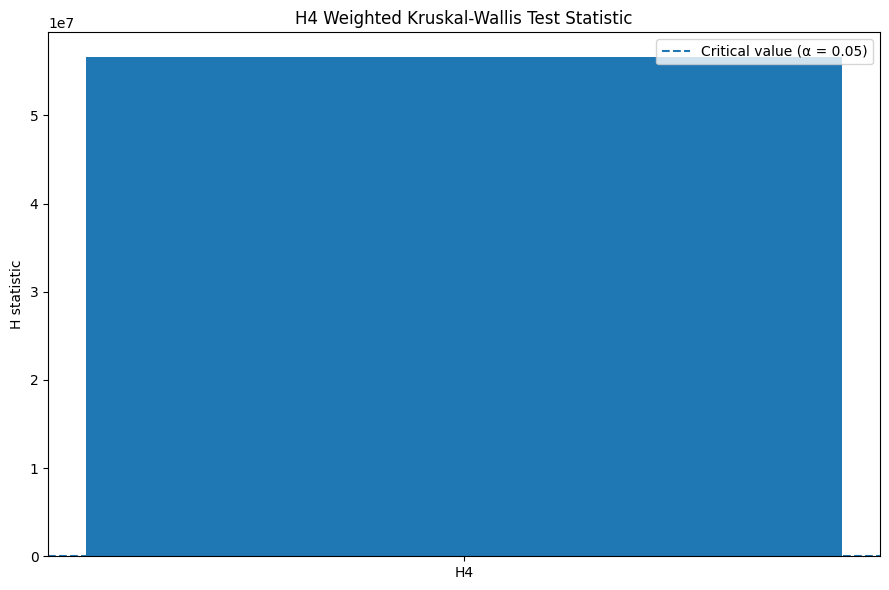

In [41]:
# H4 STATISTICAL RESULT

plt.figure(figsize=(9, 6))

plt.bar(
    ["H4"],
    [H]
)

plt.axhline(
    stats.chi2.ppf(
        1 - ALPHA,
        h4_result["df"]
    ),
    linestyle="--",
    label=f"Critical value (α = {ALPHA})"
)

plt.title("H4 Weighted Kruskal-Wallis Test Statistic")
plt.ylabel("H statistic")
plt.legend()
plt.tight_layout()
plt.show()


## Summary

### H4 conclusion

The weighted Kruskal–Wallis test evaluates whether the **reported median emergency department length of stay differs across visit disposition categories** in the aggregate `Visit_Disposition` dataset.

The result should be interpreted at the **aggregate category level**. It does not establish that individual patients in one disposition category stayed longer or shorter than individual patients in another category.

The statistical decision is based on **α = 0.05** and the reported p-value above.
